# Từ Dữ Liệu Hành Vi Đến Đề Xuất Tài Chính Cá Nhân Hóa
**G'Contest 2026** — Phân tích bộ dữ liệu Ngân hàng 2019

## ⚙️ Setup & Load Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 200)

# Màu chuẩn
BLUE  = '#0b3f8a'; LBLUE = '#8fc0ff'; GREEN = '#20a174'
ORANGE= '#ff7a22'; YELLOW= '#f7bd5b'; RED   = '#e34f4f'
DARK  = '#17202a'; GRID  = '#e6e6e6'

def sax(ax, title=None):
    if title: ax.set_title(title, loc='left', fontsize=11, fontweight='bold', color=DARK)
    ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#cccccc')

In [2]:
print("Loading cleaned data...")

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'data':
    PROJECT_DIR = PROJECT_DIR.parent

CLEANED_DIR = PROJECT_DIR / 'cleaned_data'

def read_clean_table(name):
    parquet_path = CLEANED_DIR / f'{name}_clean.parquet'
    csv_path = CLEANED_DIR / f'{name}_clean.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path, low_memory=False)
    raise FileNotFoundError(f'Cannot find {parquet_path} or {csv_path}')

cust = read_clean_table('customer')
dep = read_clean_table('deposit')
lnd = read_clean_table('lending')
crd = read_clean_table('card')
act_r = read_clean_table('activity')
txn_r = read_clean_table('transaction')

non_ib = set(cust.loc[cust['IB_REGISTER_DATE'].isna(), 'CUSTOMER_NUMBER'])
act = act_r[~act_r['CUSTOMER_NUMBER'].isin(non_ib)].copy()
txn = txn_r[~txn_r['CUSTOMER_NUMBER'].isin(non_ib)].copy()

print(
    f"customer: {len(cust):,}  |  deposit: {len(dep):,}  |  "
    f"transaction: {len(txn):,}  |  activity: {len(act):,}"
)

Loading cleaned data...


customer: 285,934  |  deposit: 1,258,424  |  transaction: 1,417,982  |  activity: 1,048,575


In [3]:
# Build customer-level base
def latest(df, cols):
    avail = [c for c in cols if c in df.columns]
    return df.sort_values(['CUSTOMER_NUMBER','MONTH']).groupby('CUSTOMER_NUMBER',as_index=False).tail(1)[['CUSTOMER_NUMBER']+avail]

base = cust.copy()
base['is_ib']       = base['IB_REGISTER_DATE'].notna()
base['AGE_AT_2019'] = (pd.Timestamp('2019-12-31') - base['DATE_OF_BIRTH']).dt.days / 365.25

for add in [latest(dep,['COUNT_CA_ACCT','AVG_CA_BALANCE','COUNT_TD_ACCT','AVG_TD_BALANCE']),
            latest(lnd,['COUNT_OF_LOAN','AVG_LOAN_AMOUNT']),
            latest(crd,['COUNT_CREDITCARD','COUNT_DEBITCARD'])]:
    base = base.merge(add, on='CUSTOMER_NUMBER', how='left')

for c in ['COUNT_CA_ACCT','COUNT_TD_ACCT','COUNT_OF_LOAN','COUNT_CREDITCARD','COUNT_DEBITCARD']:
    base[c] = base[c].fillna(0)
base['COUNT_CARD']    = base[['COUNT_CREDITCARD','COUNT_DEBITCARD']].max(axis=1)
base['product_depth'] = base[['COUNT_CA_ACCT','COUNT_TD_ACCT','COUNT_OF_LOAN','COUNT_CARD']].gt(0).sum(axis=1)

dep_c = dep.groupby('CUSTOMER_NUMBER').agg(bank_engagement_months=('MONTH','nunique'))
txn_c = txn.groupby('CUSTOMER_NUMBER').agg(
    trans_records=('TRANS_NO','size'), trans_amount=('TRANS_AMOUNT','sum'),
    trans_months=('MONTH','nunique'))
act_c = act.groupby('CUSTOMER_NUMBER').agg(
    activity_records=('ACTIVITY_NO','size'), activity_months=('MONTH','nunique'),
    login=('ACTIVITY_NAME', lambda s:(s=='LOGIN').sum()))

base = base.join(dep_c,on='CUSTOMER_NUMBER').join(txn_c,on='CUSTOMER_NUMBER').join(act_c,on='CUSTOMER_NUMBER')
base[['bank_engagement_months','trans_records','trans_amount','trans_months',
      'activity_records','activity_months','login']] =   base[['bank_engagement_months','trans_records','trans_amount','trans_months',
        'activity_records','activity_months','login']].fillna(0)
base['has_txn']      = base['trans_records'].gt(0)
base['has_activity'] = base['activity_records'].gt(0)
base['digital_engaged_months'] = base[['activity_months','trans_months']].max(axis=1)

ib  = base[base['is_ib']].copy()
non = base[~base['is_ib']].copy()
ib_no_txn = ib[~ib['has_txn']].copy()
ib_txn    = ib[ ib['has_txn']].copy()
print(f"Base: {len(base):,}  IB: {len(ib):,}  Non-IB: {len(non):,}")

Base: 285,934  IB: 158,931  Non-IB: 127,003


---
# 2. Phân Tích Tổng Quan

## Tổng quan về Ngân hàng

In [4]:
# KPI cards (in-text)
ca_sum = dep['AVG_CA_BALANCE'].fillna(0).sum()
td_sum = dep['AVG_TD_BALANCE'].fillna(0).sum()
casa   = ca_sum/(ca_sum+td_sum)*100

print("┌─────────────────────────────────────────────────────────────┐")
print(f"  Tổng KH         : {len(base):,}")
print(f"  Đã đăng ký IB   : {base['is_ib'].mean()*100:.1f}%  ({int(base['is_ib'].sum()):,} KH)")
print(f"  Non-IB          : {(~base['is_ib']).mean()*100:.1f}%  ({int((~base['is_ib']).sum()):,} KH)")
print(f"  Tuổi trung bình : {base['AGE_AT_2019'].mean():.1f}  (Median = {base['AGE_AT_2019'].median():.0f} tuổi)")
print(f"  IB avg age      : {ib['AGE_AT_2019'].mean():.1f}  |  Non-IB avg age: {non['AGE_AT_2019'].mean():.1f}")
print("└─────────────────────────────────────────────────────────────┘")

┌─────────────────────────────────────────────────────────────┐
  Tổng KH         : 285,934
  Đã đăng ký IB   : 55.6%  (158,931 KH)
  Non-IB          : 44.4%  (127,003 KH)
  Tuổi trung bình : 35.1  (Median = 33 tuổi)
  IB avg age      : 32.2  |  Non-IB avg age: 38.7
└─────────────────────────────────────────────────────────────┘


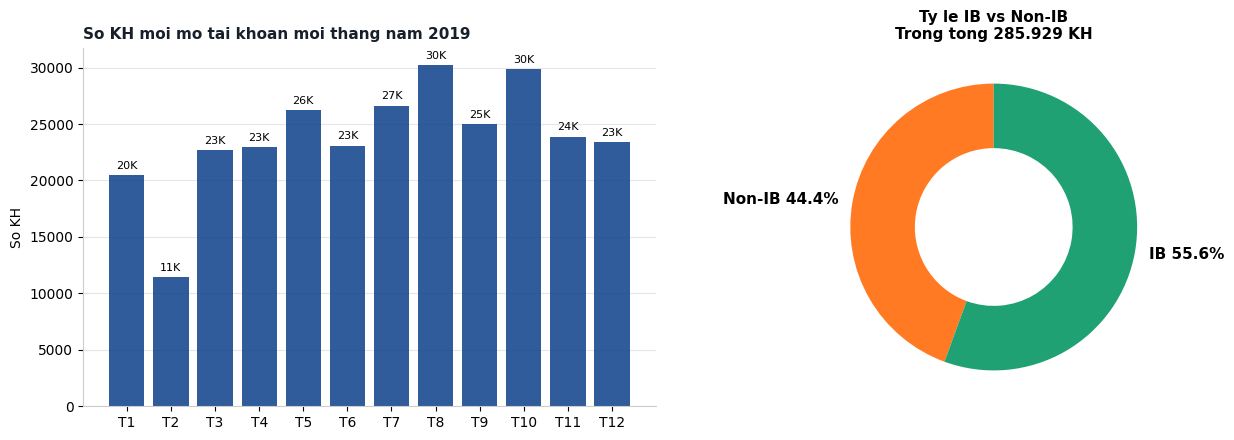

In [5]:
# Chart: Tăng trưởng mở TK + Tỷ lệ IB/Non-IB
open_m = (base.dropna(subset=['CLIENT_CREATE_DATE'])
          .assign(m=lambda x: x['CLIENT_CREATE_DATE'].dt.month)
          .groupby('m')['CUSTOMER_NUMBER'].nunique()
          .reindex(range(1,13), fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar([f'T{i}' for i in open_m.index], open_m.values, color=BLUE, alpha=0.85)
axes[0].bar_label(axes[0].containers[0], labels=[f'{v/1000:.0f}K' for v in open_m.values], fontsize=8, padding=3)
sax(axes[0], 'So KH moi mo tai khoan moi thang nam 2019')
axes[0].set_ylabel('So KH')

axes[1].pie([len(non), len(ib)],
    labels=['Non-IB 44.4%', 'IB 55.6%'],
    colors=[ORANGE, GREEN], startangle=90, wedgeprops={'width':0.45},
    textprops={'fontsize':11, 'fontweight':'bold'})
axes[1].set_title('Ty le IB vs Non-IB\nTrong tong 285.929 KH', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

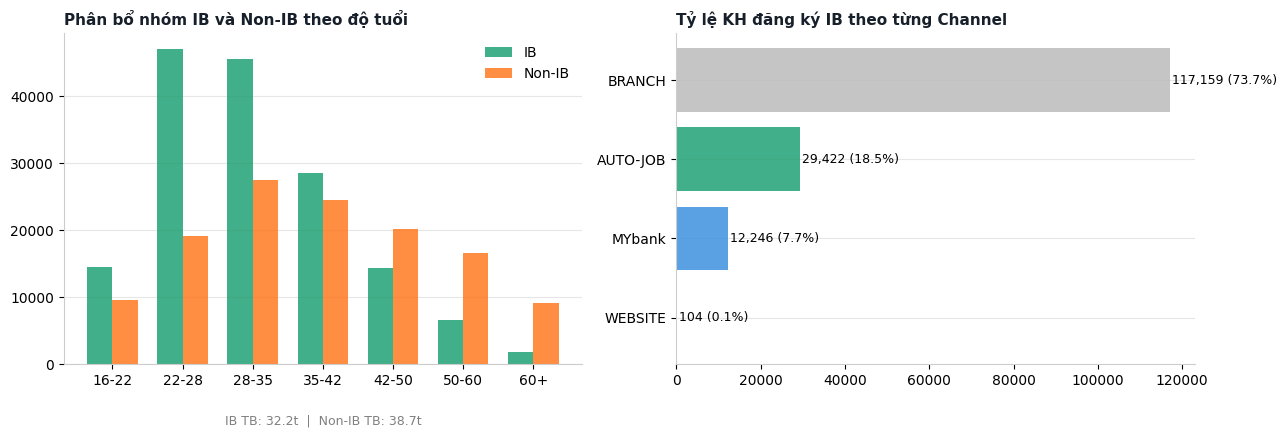

In [6]:
# Chart: Phân bổ tuổi + Kênh đăng ký IB
bins_age = [16,22,28,35,42,50,60,np.inf]
lbl_age  = ['16-22','22-28','28-35','35-42','42-50','50-60','60+']
base2 = base.assign(ab=pd.cut(base['AGE_AT_2019'],bins=bins_age,labels=lbl_age,right=False))
age_tab = (base2.pivot_table(index='ab',columns='is_ib',values='CUSTOMER_NUMBER',aggfunc='count',observed=False)
           .fillna(0).rename(columns={False:'Non-IB',True:'IB'}))

channel = ib['EB_REGISTER_CHANNEL'].fillna('UNKNOWN').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(age_tab))
axes[0].bar(x-0.18, age_tab['IB'],     0.36, label='IB',     color=GREEN,  alpha=0.85)
axes[0].bar(x+0.18, age_tab['Non-IB'], 0.36, label='Non-IB', color=ORANGE, alpha=0.85)
axes[0].set_xticks(x, age_tab.index.astype(str)); axes[0].legend(frameon=False)
sax(axes[0], 'Phân bổ nhóm IB và Non-IB theo độ tuổi')
axes[0].annotate(f'IB TB: {ib["AGE_AT_2019"].mean():.1f}t  |  Non-IB TB: {non["AGE_AT_2019"].mean():.1f}t',
    xy=(0.5,-0.18), xycoords='axes fraction', ha='center', fontsize=9, color='gray')

colors_ch = [BLUE,'#3c91df',GREEN,'#bbbbbb']
axes[1].barh(channel.index[::-1], channel.values[::-1],
    color=colors_ch[:len(channel)], alpha=0.85)
for i,(k,v) in enumerate(zip(channel.index[::-1],channel.values[::-1])):
    axes[1].text(v+500,i,f'{v:,} ({v/len(ib)*100:.1f}%)',va='center',fontsize=9)
sax(axes[1], 'Tỷ lệ KH đăng ký IB theo từng Channel')

plt.tight_layout(); plt.show()

**Nhận xét:**
Tập khách hàng trẻ, đa số dưới 35 tuổi — nhóm 15–35 chiếm 57,4% tổng KH. Nhóm IB có độ tuổi trung bình **32,2 tuổi** so với Non-IB là **38,7 tuổi** — IB trẻ hơn Non-IB đáng kể, phù hợp với xu hướng người trẻ tiếp cận digital nhanh hơn.

Hầu hết KH đăng ký IB qua chi nhánh (**73,7%**), tiếp theo là AUTO-JOB (**18,5%**) — tức KH được hệ thống tự động kích hoạt IB. Phần lớn KH được "push" lên digital từ kênh truyền thống thay vì chủ động đăng ký — điều này giải thích tại sao nhiều KH dù có IB nhưng hành vi số vẫn yếu.

---
# 3. Phân Tích Vấn Đề

## 3.1 Tăng trưởng giao dịch

In [7]:
# KPI giao dịch
outside = txn['TRANS_LV2'].eq('Outside_bank')
topup   = txn['TRANS_LV1'].eq('Topup')
out_amt = txn.loc[outside,'TRANS_AMOUNT'].sum()
top_amt = txn.loc[topup,  'TRANS_AMOUNT'].sum()

print("┌──────────────────────────────────────────────────────────────┐")
print(f"  Tổng GD 2019        : {len(txn)/1e6:.2f}M  ({len(txn):,})")
print(f"  Chuyển ngoài HT     : {outside.mean()*100:.1f}%  ({outside.sum():,} GD)")
print(f"  Outflow / Inflow    : {out_amt/top_amt:.0f}×  ({out_amt/1e9:.0f} tỷ vs {top_amt/1e9:.1f} tỷ)")
print(f"  KH có giao dịch     : {base['has_txn'].sum():,}  ({base['has_txn'].mean()*100:.1f}% tổng KH)")
print("└──────────────────────────────────────────────────────────────┘")

┌──────────────────────────────────────────────────────────────┐
  Tổng GD 2019        : 1.42M  (1,417,982)
  Chuyển ngoài HT     : 53.6%  (759,796 GD)
  Outflow / Inflow    : 130×  (9324 tỷ vs 71.8 tỷ)
  KH có giao dịch     : 52,481  (18.4% tổng KH)
└──────────────────────────────────────────────────────────────┘


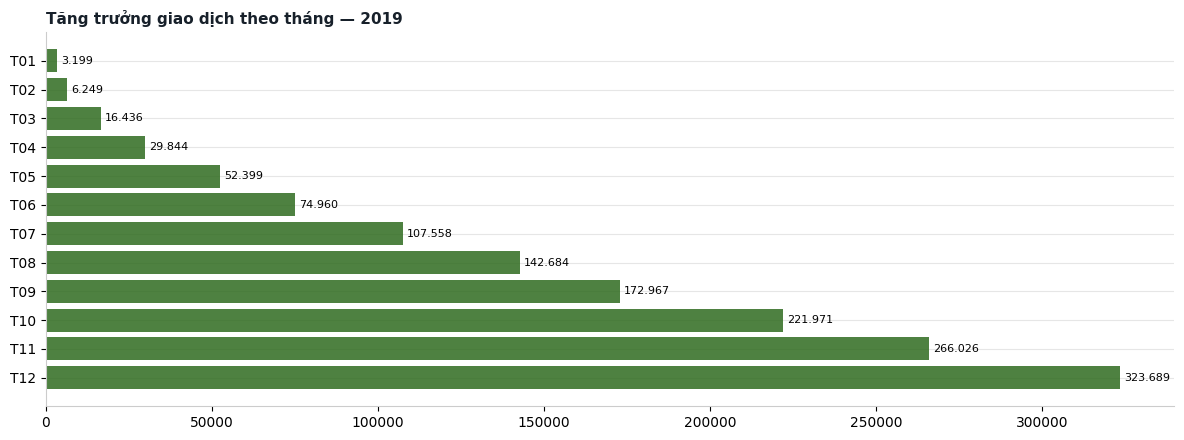

T01: 3,199 GD  →  T12: 323,689 GD  (101x tăng trưởng)


In [8]:
# Chart: Tăng trưởng GD theo tháng
txn_m = (txn.groupby(txn['TRANS_DATE'].dt.month).size().reindex(range(1,13),fill_value=0))
t1, t12 = txn_m[1], txn_m[12]

plt.figure(figsize=(12,4.5))
bars = plt.barh([f'T{i:02d}' for i in txn_m.index], txn_m.values, color='#2f6b1f', alpha=0.85)
plt.bar_label(bars, labels=[f'{v:,.0f}'.replace(',','.') for v in txn_m.values], padding=3, fontsize=8)
plt.gca().invert_yaxis()
sax(plt.gca(), 'Tăng trưởng giao dịch theo tháng — 2019')
plt.tight_layout(); plt.show()
print(f"T01: {t1:,} GD  →  T12: {t12:,} GD  ({t12/t1:.0f}x tăng trưởng)")

**Nhận xét:**
Dù giao dịch tăng trưởng ấn tượng — gấp hơn **100 lần** từ T1 (3.199 GD) đến T12 (323.689 GD), phần lớn phản ánh việc ngân hàng liên tục tích lũy khách hàng mới trong năm 2019 hơn là hành vi giao dịch thực sự cải thiện. Chất lượng giao dịch vẫn đặt ra nhiều dấu hỏi: **53,6%** giao dịch là chuyển tiền ra ngoài hệ thống, và outflow vượt inflow tới **130 lần** (9.324 tỷ vs 71,8 tỷ VNĐ). Chỉ **18,4%** khách hàng thực sự có giao dịch — đại đa số còn lại dù có tài khoản vẫn hoàn toàn thụ động.

## 3.2 Tiền gửi không kỳ hạn — CASA 8,7%: KH không cảm thấy cần giữ tiền tại NH

In [9]:
# KPI CASA
ca_tot = dep['AVG_CA_BALANCE'].fillna(0).sum()
td_tot = dep['AVG_TD_BALANCE'].fillna(0).sum()
casa   = ca_tot/(ca_tot+td_tot)*100
med_ca_all = base.loc[base['AVG_CA_BALANCE'].fillna(0).gt(0),'AVG_CA_BALANCE'].median()
med_ca_non = non.loc[ non['AVG_CA_BALANCE'].fillna(0).gt(0),'AVG_CA_BALANCE'].median()
med_td_all = base.loc[base['AVG_TD_BALANCE'].fillna(0).gt(0),'AVG_TD_BALANCE'].median()
no_deposit = (base[['AVG_CA_BALANCE','AVG_TD_BALANCE']].fillna(0).sum(axis=1).eq(0)).mean()*100

print(f"  CASA ratio          : {casa:.1f}%  (chuẩn ngành tốt ~30%  →  thấp hơn {30/casa:.1f}×)")
print(f"  Median CA (toàn NH) : {med_ca_all/1e3:.0f}K")
print(f"  Median CA (Non-IB)  : {med_ca_non/1e3:.0f}K")
print(f"  Median TD (toàn NH) : {med_td_all/1e6:.0f}M")
print(f"  KH không có tiền gửi: {no_deposit:.1f}%")

  CASA ratio          : 8.7%  (chuẩn ngành tốt ~30%  →  thấp hơn 3.4×)
  Median CA (toàn NH) : 355K
  Median CA (Non-IB)  : 215K
  Median TD (toàn NH) : 120M
  KH không có tiền gửi: 23.0%


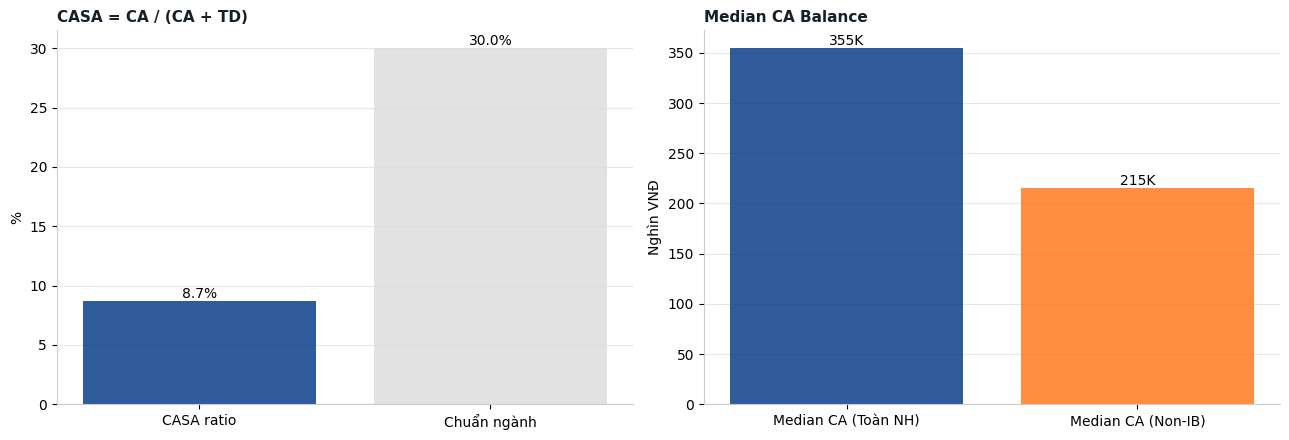

In [10]:
# Chart: CASA + median CA balance
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].bar(['CASA ratio','Chuẩn ngành'], [casa, 30], color=[BLUE, '#dddddd'], alpha=0.85)
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')
sax(axes[0], 'CASA = CA / (CA + TD)')
axes[0].set_ylabel('%')

categories = ['Median CA (Toàn NH)', 'Median CA (Non-IB)']
values = [med_ca_all/1e3, med_ca_non/1e3]
axes[1].bar(categories, values, color=[BLUE, ORANGE], alpha=0.85)
axes[1].bar_label(axes[1].containers[0], labels=[f'{v:.0f}K' for v in values])
sax(axes[1], 'Median CA Balance')
axes[1].set_ylabel('Nghìn VNĐ')

plt.tight_layout(); plt.show()

**Nhận xét:**
CASA chỉ **8,7%** — thấp hơn khoảng **3,4 lần** so với chuẩn ngành tốt (~30%). Median CA balance của một KH chỉ **355K đồng** (toàn NH) và **215K đồng** (Non-IB) — số tiền đủ để thực hiện 1–2 giao dịch rồi hết.

**TIỀN CÓ — NHƯNG KHÔNG NẰM Ở TÀI KHOẢN THANH TOÁN:** CASA thấp không phải vì KH không có tiền: median TD lên tới **120M**, gấp hàng trăm lần CA balance. Họ để tiền ở tiết kiệm kỳ hạn và rút/chuyển ngay khi cần (outflow 130× inflow), thay vì giữ tiền sống trong tài khoản để chi tiêu. Ngân hàng đang được tin để cất tiền, nhưng chưa được chọn làm nơi tiêu tiền.

## 3.3 Gắn kết sản phẩm — Đa số KH chỉ "thử" NH với 1–2 sản phẩm

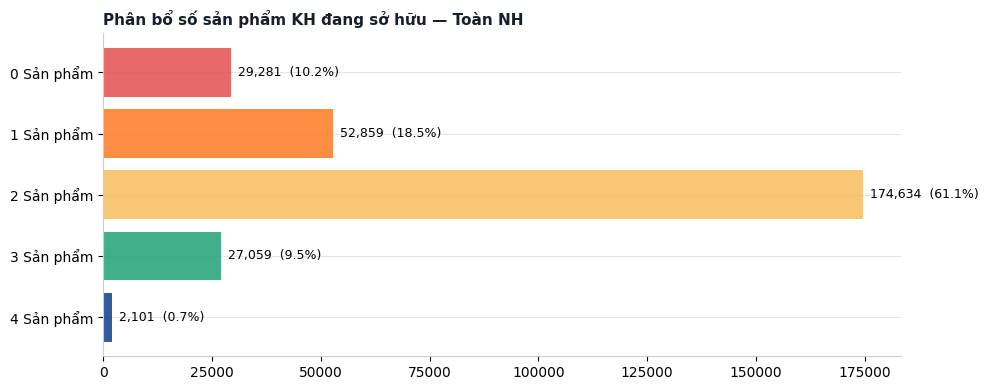

≤2 SP: 256,774 (89.8%)  |  Mean SP/KH: 1.72


In [11]:
# Chart: Phân bổ SP toàn NH
depth_c = base['product_depth'].value_counts().sort_index()

plt.figure(figsize=(10,4))
bars = plt.barh([f'{int(i)} Sản phẩm' for i in depth_c.index], depth_c.values,
    color=[RED,ORANGE,YELLOW,GREEN,BLUE][:len(depth_c)], alpha=0.85)
plt.bar_label(bars, labels=[f'{v:,}  ({v/len(base)*100:.1f}%)' for v in depth_c.values], padding=5, fontsize=9)
sax(plt.gca(), 'Phân bổ số sản phẩm KH đang sở hữu — Toàn NH')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

le2 = base['product_depth'].le(2).sum()
print(f"≤2 SP: {le2:,} ({le2/len(base)*100:.1f}%)  |  Mean SP/KH: {base['product_depth'].mean():.2f}")

**Nhận xét:**
**61,1% khách hàng đang dừng lại ở đúng 2 sản phẩm**, như thể họ đã "thử" NH ở mức tối thiểu rồi không có lý do để tiếp tục sâu hơn. Chỉ **10,2% KH** vươn lên được 3 sản phẩm trở lên — cho thấy rào cản bước nhảy từ 2 lên 3 SP là rất rõ ràng.

Khoảng trống thực sự nằm ở bước nhảy từ **2 lên 3 sản phẩm** — tiềm năng cross-sell rất lớn nhưng NH chưa có cơ chế nhận diện ai sẵn sàng và đề xuất đúng lúc.

## 3.4 Hành vi hoạt động — 67% KH IB chưa bao giờ giao dịch

In [12]:
# KPI hành vi
no_txn_n  = (~ib['has_txn']).sum()
no_act_n  = (~ib['has_activity']).sum()
act_1_2   = ib['digital_engaged_months'].between(1,2).sum()
act_6p    = ib['digital_engaged_months'].ge(6).sum()

sms_rate  = ib.groupby('SMS')['has_txn'].mean()*100

print(f"  IB chưa GD              : {no_txn_n:,}  ({no_txn_n/len(ib)*100:.1f}%)")
print(f"  IB chưa login lần nào   : {no_act_n:,}  ({no_act_n/len(ib)*100:.1f}%)")
print(f"  Active chỉ 1–2 tháng    : {act_1_2:,}  ({act_1_2/len(ib)*100:.1f}% tổng IB)")
print(f"  Active 6+ tháng         : {act_6p:,}  ({act_6p/len(ib)*100:.1f}%  — gắn kết thực sự)")
print(f"  Txn rate có SMS         : {sms_rate.get('Y',0):.1f}%  vs không SMS: {sms_rate.get('N',0):.1f}%")

  IB chưa GD              : 106,450  (67.0%)
  IB chưa login lần nào   : 141,158  (88.8%)
  Active chỉ 1–2 tháng    : 22,897  (14.4% tổng IB)
  Active 6+ tháng         : 16,980  (10.7%  — gắn kết thực sự)
  Txn rate có SMS         : 41.8%  vs không SMS: 22.3%


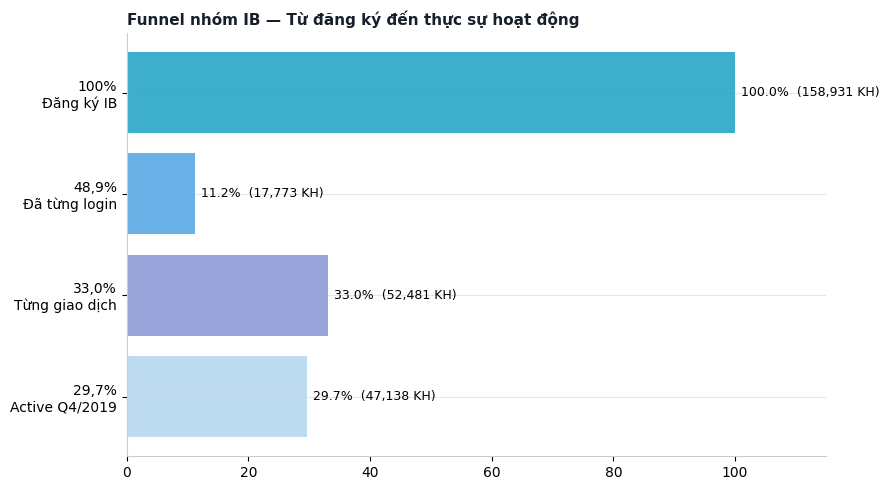

In [13]:
# Chart: Funnel IB
q4 = pd.to_datetime(['2019-10-31','2019-11-30','2019-12-31'])
ib_ids = set(ib['CUSTOMER_NUMBER'])
funnel = pd.Series({
    '100%\nĐăng ký IB'       : len(ib),
    '48,9%\nĐã từng login'   : act['CUSTOMER_NUMBER'].isin(ib_ids).sum() if False else ib['has_activity'].sum(),
    '33,0%\nTừng giao dịch'  : ib['has_txn'].sum(),
    '29,7%\nActive Q4/2019'  : txn.loc[txn['CUSTOMER_NUMBER'].isin(ib_ids)&txn['MONTH'].isin(q4),'CUSTOMER_NUMBER'].nunique(),
})
pct = funnel / len(ib) * 100

fig, ax = plt.subplots(figsize=(9,5))
colors_f = ['#b6d7f0','#8e9ad7','#5aa9e6','#28a7c8']
ax.barh(funnel.index[::-1], pct.values[::-1], color=colors_f, alpha=0.9)
for y,(lbl,v,c) in enumerate(zip(funnel.index[::-1],pct.values[::-1],funnel.values[::-1])):
    ax.text(v+1, y, f'{v:.1f}%  ({c:,} KH)', va='center', fontsize=9)
ax.set_xlim(0,115)
sax(ax, 'Funnel nhóm IB — Từ đăng ký đến thực sự hoạt động')
plt.tight_layout(); plt.show()

**Nhận xét:**
**Bức tranh active phân tầng rõ:** chỉ **8,1%** KH IB thực sự gắn kết, trong khi **67%** không để lại bất kỳ dấu vết giao dịch nào — và đáng chú ý hơn, **75,9%** trong số đó thậm chí không mở app lần nào.

Tỷ lệ rơi rụng dồn hết về giai đoạn đầu — trong số KH đăng ký từ T1 đến T9 (có đủ thời gian cả năm), vẫn có tới **45,4%** tổng IB không phát sinh giao dịch.

Đây là tín hiệu của vấn đề **first-use**, không phải vấn đề nhu cầu: NH chưa tạo được cú hích để KH mở app và thực hiện giao dịch đầu tiên.

## 3.5 Sự phân hoá — Hai nhóm cùng là KH nhưng hoàn toàn khác biệt

In [14]:
# Bảng so sánh IB vs Non-IB
ib_ca_mean  = ib['AVG_CA_BALANCE'].fillna(0).mean()/1e6
non_td_mean = non['AVG_TD_BALANCE'].fillna(0).mean()/1e6
ib_td_mean  = ib['AVG_TD_BALANCE'].fillna(0).mean()/1e6

print("╔══════════════════════════════╦══════════════════════════════╗")
print("║  NHÓM IB · 158.929 KH       ║  NHÓM NON-IB · 127.000 KH   ║")
print("╠══════════════════════════════╬══════════════════════════════╣")
print(f"║  100% giao dịch từ nhóm này ║  Gần như 0 GD số             ║")
print(f"║  Nhưng chỉ 33% KH tạo GD   ║  TD balance TB: {non_td_mean:.0f}M        ║")
print(f"║  CA balance TB: {ib_ca_mean:.2f}M     ║  Cao hơn IB khi tính toàn nhóm║")
print(f"║  53%+ GD chuyển ngoài HT    ║  Tương tác qua chi nhánh     ║")
print(f"║  67% chưa bao giờ GD        ║  Không có dữ liệu hành vi số ║")
print("╚══════════════════════════════╩══════════════════════════════╝")
print()
print("  → IB: cần giữ lại và deepening — gợi ý SP phù hợp với hành vi thực tế")
print("  → Non-IB: cần được 'tìm thấy' trước — hiểu họ qua demographic & balance")

╔══════════════════════════════╦══════════════════════════════╗
║  NHÓM IB · 158.929 KH       ║  NHÓM NON-IB · 127.000 KH   ║
╠══════════════════════════════╬══════════════════════════════╣
║  100% giao dịch từ nhóm này ║  Gần như 0 GD số             ║
║  Nhưng chỉ 33% KH tạo GD   ║  TD balance TB: 52M        ║
║  CA balance TB: 5.08M     ║  Cao hơn IB khi tính toàn nhóm║
║  53%+ GD chuyển ngoài HT    ║  Tương tác qua chi nhánh     ║
║  67% chưa bao giờ GD        ║  Không có dữ liệu hành vi số ║
╚══════════════════════════════╩══════════════════════════════╝

  → IB: cần giữ lại và deepening — gợi ý SP phù hợp với hành vi thực tế
  → Non-IB: cần được 'tìm thấy' trước — hiểu họ qua demographic & balance


## 3.6 Kết luận — Vấn đề trung tâm

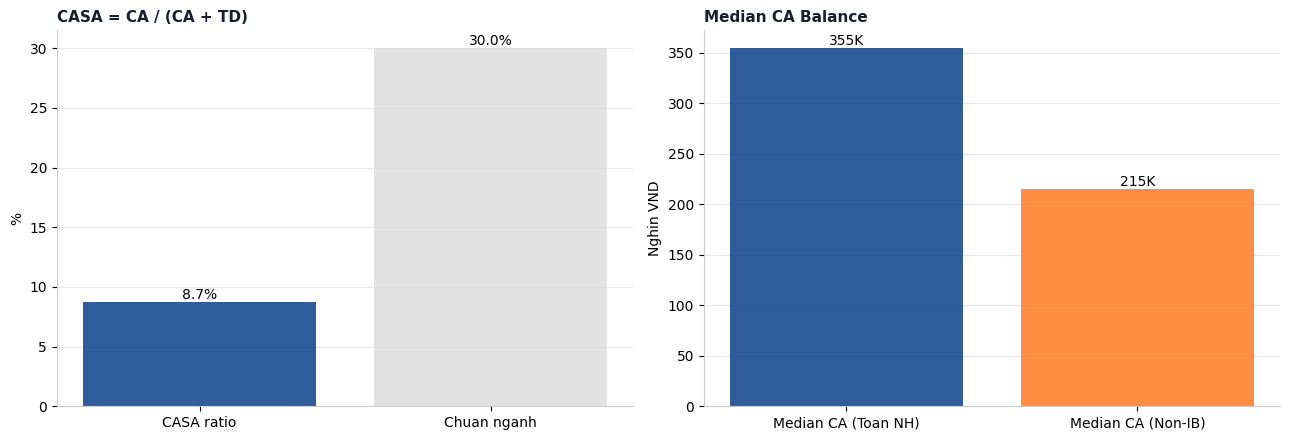

CASA: 8.7%  Median CA: 355K  Median TD: 120M  No deposit: 23.0%


In [15]:
# Chart: CASA + median CA balance
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(['CASA ratio', 'Chuan nganh'], [casa, 30], color=[BLUE, '#dddddd'], alpha=0.85)
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')
sax(axes[0], 'CASA = CA / (CA + TD)')
axes[0].set_ylabel('%')

med_ca_all = base.loc[base['AVG_CA_BALANCE'].fillna(0).gt(0), 'AVG_CA_BALANCE'].median()
med_ca_non = non.loc[non['AVG_CA_BALANCE'].fillna(0).gt(0), 'AVG_CA_BALANCE'].median()
med_td_all = base.loc[base['AVG_TD_BALANCE'].fillna(0).gt(0), 'AVG_TD_BALANCE'].median()

cats = ['Median CA (Toan NH)', 'Median CA (Non-IB)']
vals = [med_ca_all/1e3, med_ca_non/1e3]
axes[1].bar(cats, vals, color=[BLUE, ORANGE], alpha=0.85)
axes[1].bar_label(axes[1].containers[0], labels=[f'{v:.0f}K' for v in vals])
sax(axes[1], 'Median CA Balance')
axes[1].set_ylabel('Nghin VND')

plt.tight_layout()
plt.show()
no_deposit = (base[['AVG_CA_BALANCE','AVG_TD_BALANCE']].fillna(0).sum(axis=1).eq(0)).mean()*100
print(f"CASA: {casa:.1f}%  Median CA: {med_ca_all/1e3:.0f}K  Median TD: {med_td_all/1e6:.0f}M  No deposit: {no_deposit:.1f}%")

**Kết luận:**
Ngân hàng có đủ khách hàng, có nền tảng số, có sản phẩm — nhưng chưa hiểu đủ về từng khách hàng để giữ họ lại và phục vụ đúng nhu cầu.

Cần hai hướng tiếp cận riêng biệt — IB và Non-IB có hành vi và dữ liệu hoàn toàn khác nhau:
- **Bài toán IB:** Có hành vi giao dịch đầy đủ → dùng dữ liệu hành vi để dự đoán SP tiếp theo phù hợp nhất
- **Bài toán Non-IB:** Không có hành vi số → phân nhóm theo đặc điểm tài chính để hiểu họ là ai trước khi tiếp cận

---
# 4. Phân Tích Vấn Đề — Nhóm IB (158.929 KH)

## 4.1 Chỉ ⅓ Khách hàng IB thực sự giao dịch

In [16]:
# KPI chi tiết nhóm IB
no_txn_n = (~ib['has_txn']).sum()
no_act_n = (~ib['has_activity']).sum()
act_12   = ib['digital_engaged_months'].between(1,2).sum()
act_6p   = ib['digital_engaged_months'].ge(6).sum()

print(f"  Chưa GD lần nào                  : {no_txn_n:,}  ({no_txn_n/len(ib)*100:.1f}%)")
print(f"  Chưa login lần nào               : {no_act_n:,}  ({no_act_n/len(ib)*100:.1f}%)")
print(f"  Đã từng login                    : {ib['has_activity'].sum():,}")
print(f"  Active 1–2 tháng (tổng IB)       : {act_12:,}  ({act_12/len(ib)*100:.1f}%)")
print(f"    = {act_12/ib['has_txn'].sum()*100:.1f}% trong số KH IB có GD")
print(f"  Active 6+ tháng (gắn kết thực sự): {act_6p:,}  ({act_6p/len(ib)*100:.1f}%)")
print()
print("  Trong mỗi 10 KH đăng ký IB:")
print("    → chỉ ~3 người dùng")
print("    → trong 3 đó chỉ 1–2 người gắn kết lâu dài")

  Chưa GD lần nào                  : 106,450  (67.0%)
  Chưa login lần nào               : 141,158  (88.8%)
  Đã từng login                    : 17,773
  Active 1–2 tháng (tổng IB)       : 22,897  (14.4%)
    = 43.6% trong số KH IB có GD
  Active 6+ tháng (gắn kết thực sự): 16,980  (10.7%)

  Trong mỗi 10 KH đăng ký IB:
    → chỉ ~3 người dùng
    → trong 3 đó chỉ 1–2 người gắn kết lâu dài


## 4.2 Phân tích chi tiết ⅔ KH IB không giao dịch

In [17]:
# 95.6% vẫn có SP + so sánh sở hữu SP
sp_no  = ib_no_txn['product_depth'].ge(1).mean()*100
sp_0_no= ib_no_txn['product_depth'].eq(0).mean()*100
avg_no = ib_no_txn['product_depth'].mean()
avg_ys = ib_txn['product_depth'].mean()

print(f"  95,6% nhóm không GD vẫn có quan hệ với NH qua SP:")
print(f"    Có ≥1 SP : {ib_no_txn['product_depth'].ge(1).sum():,}  ({sp_no:.1f}%)")
print(f"    Không SP : {ib_no_txn['product_depth'].eq(0).sum():,}  ({sp_0_no:.2f}%)")
print(f"    Avg SP/KH: {avg_no:.2f}  vs  có GD: {avg_ys:.2f}")

compare_cols = ['COUNT_CA_ACCT','COUNT_OF_LOAN','COUNT_DEBITCARD','COUNT_CREDITCARD','COUNT_TD_ACCT']
comp = pd.DataFrame({
    '67% không GD qua IB': ib_no_txn[compare_cols].gt(0).mean()*100,
    '33% có GD qua IB'   : ib_txn[compare_cols].gt(0).mean()*100,
}).rename(index={'COUNT_CA_ACCT':'Deposit (CA)','COUNT_OF_LOAN':'Vay',
    'COUNT_DEBITCARD':'Debit Card','COUNT_CREDITCARD':'Credit Card','COUNT_TD_ACCT':'Tiết kiệm (TD)'})
print()
print(comp.to_string())

  95,6% nhóm không GD vẫn có quan hệ với NH qua SP:
    Có ≥1 SP : 101,753  (95.6%)
    Không SP : 4,697  (4.41%)
    Avg SP/KH: 1.89  vs  có GD: 2.20

                67% không GD qua IB  33% có GD qua IB
Deposit (CA)              69.133866         99.670357
Vay                       48.387036         22.219470
Debit Card                35.868483         77.915817
Credit Card               27.472992         15.813342
Tiết kiệm (TD)             8.802255         10.287533


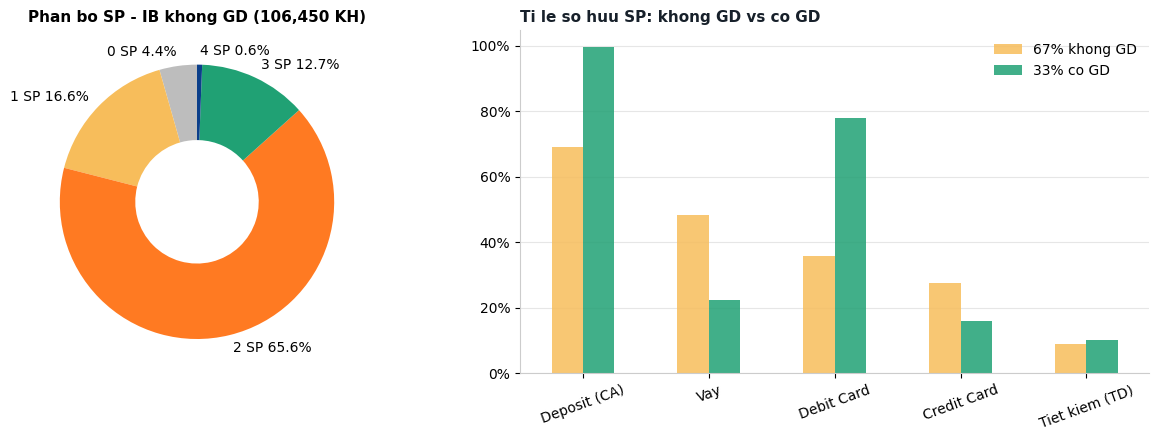

In [18]:
# Chart: Phan bo SP (no GD) + So sanh so huu SP
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

depth_no = ib_no_txn['product_depth'].value_counts(normalize=True).sort_index() * 100
labels_pie = [f'{int(i)} SP {v:.1f}%' for i, v in depth_no.items()]
axes[0].pie(depth_no.values, labels=labels_pie,
    colors=['#bdbdbd', YELLOW, ORANGE, GREEN, BLUE][:len(depth_no)],
    startangle=90, wedgeprops={'width':0.55})
axes[0].set_title(f'Phan bo SP - IB khong GD ({len(ib_no_txn):,} KH)', fontsize=11, fontweight='bold')

compare_cols = ['COUNT_CA_ACCT','COUNT_OF_LOAN','COUNT_DEBITCARD','COUNT_CREDITCARD','COUNT_TD_ACCT']
comp = pd.DataFrame({
    '67% khong GD': ib_no_txn[compare_cols].gt(0).mean() * 100,
    '33% co GD'   : ib_txn[compare_cols].gt(0).mean() * 100,
}).rename(index={'COUNT_CA_ACCT':'Deposit (CA)', 'COUNT_OF_LOAN':'Vay',
    'COUNT_DEBITCARD':'Debit Card', 'COUNT_CREDITCARD':'Credit Card', 'COUNT_TD_ACCT':'Tiet kiem (TD)'})
comp.plot(kind='bar', ax=axes[1], color=[YELLOW, GREEN], alpha=0.85)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(frameon=False)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[1], 'Ti le so huu SP: khong GD vs co GD')

plt.tight_layout()
plt.show()

**Nhận xét:**
**95,6%** trong nhóm "không giao dịch số" vẫn đang có quan hệ với Ngân hàng qua sản phẩm. Họ không rời bỏ Ngân hàng — họ chỉ chưa sử dụng kênh digital để giao dịch.

Nhóm 67% có tỷ lệ Vay **48,4% vs 22,2%** và Credit Card **27,5% vs 15,8%** — cao hơn đáng kể so với nhóm có GD. Họ đang có quan hệ tài chính với ngân hàng, chỉ là theo hướng vay/tích lũy tại chi nhánh thay vì giao dịch số hàng ngày.

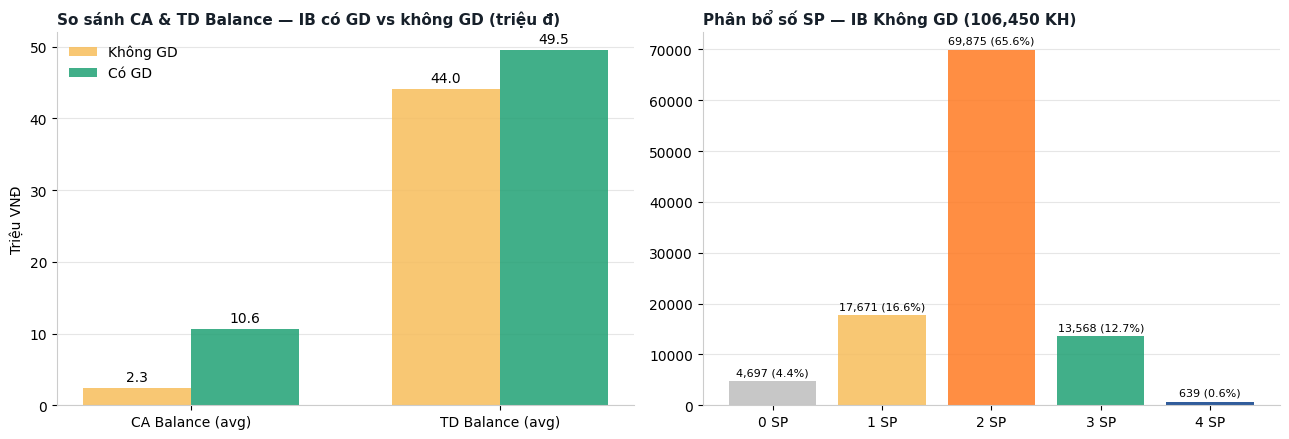

TD balance TB (không GD): 44.0M  vs  có GD: 49.5M
86,7% ≤2 SP: 92,243
Cross-sell target — có vay chưa TD: 50,083  |  có CA chưa GD: 73,593


In [19]:
# Chart: So sánh CA & TD balance + Phân bổ SP no GD
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

# Balance comparison
ca_no = ib_no_txn['AVG_CA_BALANCE'].fillna(0).mean()/1e6
ca_ys = ib_txn['AVG_CA_BALANCE'].fillna(0).mean()/1e6
td_no = ib_no_txn['AVG_TD_BALANCE'].fillna(0).mean()/1e6
td_ys = ib_txn['AVG_TD_BALANCE'].fillna(0).mean()/1e6

x = np.arange(2); w = 0.35
axes[0].bar(x-w/2,[ca_no,td_no],w,label='Không GD',color=YELLOW,alpha=0.85)
axes[0].bar(x+w/2,[ca_ys,td_ys],w,label='Có GD',   color=GREEN, alpha=0.85)
axes[0].set_xticks(x,['CA Balance (avg)','TD Balance (avg)'])
for bar in axes[0].containers: axes[0].bar_label(bar,fmt='%.1f',padding=3)
axes[0].set_ylabel('Triệu VNĐ'); axes[0].legend(frameon=False)
sax(axes[0],'So sánh CA & TD Balance — IB có GD vs không GD (triệu đ)')

# Product depth distribution
dist_no = ib_no_txn['product_depth'].value_counts().sort_index()
axes[1].bar([f'{int(i)} SP' for i in dist_no.index], dist_no.values,
    color=['#bdbdbd',YELLOW,ORANGE,GREEN,BLUE][:len(dist_no)], alpha=0.85)
axes[1].bar_label(axes[1].containers[0],
    labels=[f'{v:,} ({v/len(ib_no_txn)*100:.1f}%)' for v in dist_no.values], fontsize=8, padding=3)
sax(axes[1],f'Phân bổ số SP — IB Không GD ({len(ib_no_txn):,} KH)')

plt.tight_layout(); plt.show()

print(f"TD balance TB (không GD): {td_no:.1f}M  vs  có GD: {td_ys:.1f}M")
print(f"86,7% ≤2 SP: {ib_no_txn['product_depth'].le(2).sum():,}")
lv_no_td = (ib_no_txn['COUNT_OF_LOAN'].gt(0) & ib_no_txn['COUNT_TD_ACCT'].eq(0)).sum()
print(f"Cross-sell target — có vay chưa TD: {lv_no_td:,}  |  có CA chưa GD: {ib_no_txn['COUNT_CA_ACCT'].gt(0).sum():,}")

## 4.3 Phân tích toàn bộ nhóm IB — Product Depth & Loyalty

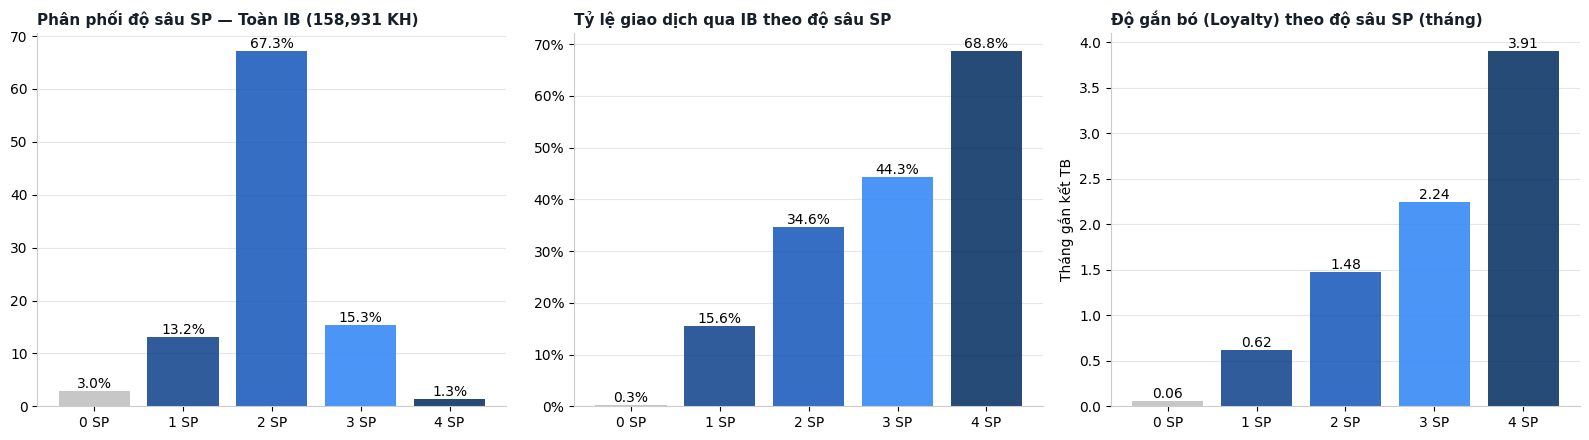

67,3% kẹt 2 SP  |  4 SP txn: 68.8% (2.0× nhóm 2 SP 34.6%)
4 SP loyalty: 3.91T (2.6× nhóm 2 SP 1.48T)


In [20]:
# Chart: Product depth + Txn rate + Loyalty
depth_ib = ib['product_depth'].value_counts(normalize=True).sort_index()*100
txr_dep  = ib.groupby('product_depth')['has_txn'].mean()*100
loy_dep  = ib.groupby('product_depth')['digital_engaged_months'].mean()
colors_d = ['#bdbdbd',BLUE,'#1155b8','#2b83f6','#002b5f']

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))

axes[0].bar([f'{int(i)} SP' for i in depth_ib.index], depth_ib.values,
    color=colors_d[:len(depth_ib)], alpha=0.85)
axes[0].bar_label(axes[0].containers[0],fmt='%.1f%%')
sax(axes[0],f'Phân phối độ sâu SP — Toàn IB ({len(ib):,} KH)')

axes[1].bar([f'{int(i)} SP' for i in txr_dep.index], txr_dep.values,
    color=colors_d[:len(txr_dep)], alpha=0.85)
axes[1].bar_label(axes[1].containers[0],fmt='%.1f%%')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[1],'Tỷ lệ giao dịch qua IB theo độ sâu SP')

axes[2].bar([f'{int(i)} SP' for i in loy_dep.index], loy_dep.values,
    color=colors_d[:len(loy_dep)], alpha=0.85)
axes[2].bar_label(axes[2].containers[0],fmt='%.2f')
axes[2].set_ylabel('Tháng gắn kết TB')
sax(axes[2],'Độ gắn bó (Loyalty) theo độ sâu SP (tháng)')

plt.tight_layout(); plt.show()

r2=txr_dep.get(2,0); r4=txr_dep.get(4,0); l2=loy_dep.get(2,0); l4=loy_dep.get(4,0)
print(f"67,3% kẹt 2 SP  |  4 SP txn: {r4:.1f}% ({r4/r2:.1f}× nhóm 2 SP {r2:.1f}%)")
print(f"4 SP loyalty: {l4:.2f}T ({l4/l2:.1f}× nhóm 2 SP {l2:.2f}T)")

**Nhận xét:**
**67,3%** KH đang kẹt ở đúng 2 sản phẩm — nhóm lớn nhất và cũng là target chính.

**Vòng lặp tích cực đã được chứng minh:** KH có 4 SP giao dịch với tỷ lệ **68,8%** — gấp đôi nhóm 2 SP (34,6%) và gấp 4,4 lần nhóm 1 SP (15,6%). Loyalty 4 SP đạt **4,90 tháng** vs 2 SP chỉ **2,04 tháng** — gấp **2,4 lần**.

Nhảy lớn nhất ở bước từ 3 lên 4 SP: **3,10T → 4,90T** (+1,8T). Cross-sell không chỉ tăng doanh thu — nó giữ khách hàng ở lại lâu hơn.

## 4.4 Hai vấn đề chính — Nhóm IB

### VẤN ĐỀ 1: ONBOARDING
> **67% KH IB không giao dịch — không phải vì họ không muốn, mà vì họ chưa bao giờ thực sự được onboard**

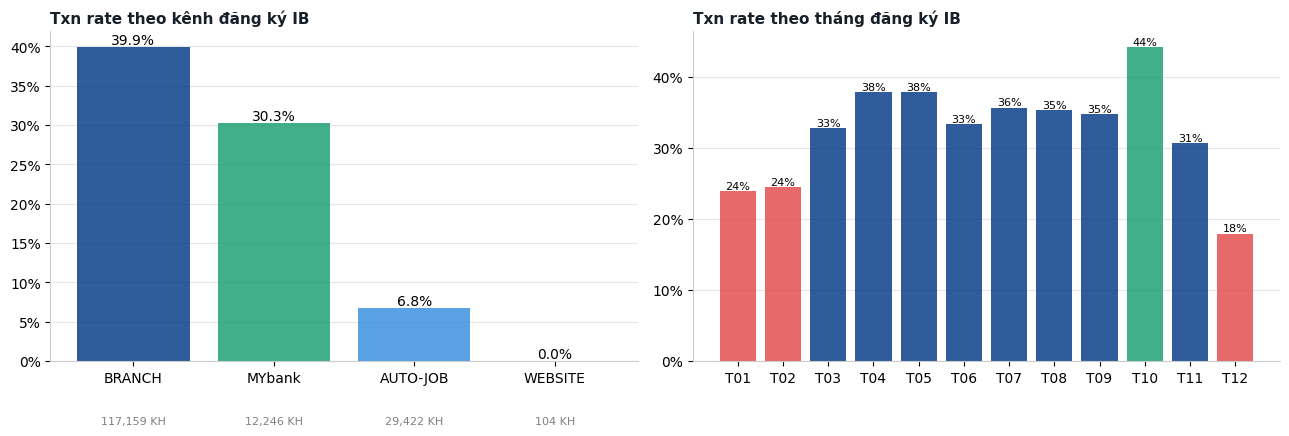

AUTO-JOB: 6.8%  BRANCH: 39.9%  MYbank: 30.3%
BRANCH/AUTO: 5.9×  |  MYbank/AUTO: 4.5×
T10: 44.3%  T12: 18.0%


In [21]:
# Chart: Txn rate theo kênh + tháng
ch_rate  = ib.groupby('EB_REGISTER_CHANNEL')['has_txn'].mean().sort_values(ascending=False)*100
ch_count = ib['EB_REGISTER_CHANNEL'].value_counts()
m_rate   = ib.assign(rm=ib['IB_REGISTER_DATE'].dt.month).groupby('rm')['has_txn'].mean().reindex(range(1,13))*100

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

bars = axes[0].bar(ch_rate.index.astype(str), ch_rate.values,
    color=[BLUE,GREEN,'#3c91df','#bbbbbb'][:len(ch_rate)], alpha=0.85)
axes[0].bar_label(bars,fmt='%.1f%%')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[0],'Txn rate theo kênh đăng ký IB')
for i,(k,v) in enumerate(zip(ch_rate.index,ch_rate.values)):
    n=ch_count.get(k,0)
    axes[0].text(i,-8,f'{n:,} KH',ha='center',fontsize=8,color='gray')

colors_m = [RED if v<25 else (GREEN if v>40 else BLUE) for v in m_rate.values]
bars2 = axes[1].bar([f'T{i:02d}' for i in m_rate.index], m_rate.values,
    color=colors_m, alpha=0.85)
axes[1].bar_label(bars2,fmt='%.0f%%',fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[1],'Txn rate theo tháng đăng ký IB')

plt.tight_layout(); plt.show()

auto=ch_rate.get('AUTO-JOB',0); br=ch_rate.get('BRANCH',0); my=ch_rate.get('MYbank',0)
print(f"AUTO-JOB: {auto:.1f}%  BRANCH: {br:.1f}%  MYbank: {my:.1f}%")
print(f"BRANCH/AUTO: {br/auto:.1f}×  |  MYbank/AUTO: {my/auto:.1f}×")
print(f"T10: {m_rate[10]:.1f}%  T12: {m_rate[12]:.1f}%")

**Phân tích:**
AUTO-JOB (**6,8%** txn rate) thấp hơn **5,9 lần** so với BRANCH (**39,9%**) và **4,5 lần** so với MYbank (**30,2%**). AUTO-JOB và WEBSITE là hệ quả điển hình của việc NH tập trung vào số lượng onboard mà bỏ qua chất lượng activation.

KH đăng ký tháng 12: txn rate chỉ **18,0%** vs tháng 10 **44,3%** — onboard ồ ạt cuối năm không kịp activation.

**Hướng tiếp cận:** Nhóm KH IB chưa từng giao dịch trung thành với NH qua kênh truyền thống — chỉ chưa được dẫn dắt vào kênh số. Đây là cơ hội activation lớn nhất mà NH hiện đang bỏ ngỏ.

### VẤN ĐỀ 2: GẮN KẾT & CROSS-SELL
> **NH đang có KH nhưng chưa thực sự hiểu họ cần gì tiếp theo**

In [22]:
# Cross-sell signals
has_dep = ib_txn['COUNT_CA_ACCT'].gt(0) | ib_txn['COUNT_TD_ACCT'].gt(0)
dep_no_loan = has_dep & ib_txn['COUNT_OF_LOAN'].eq(0)
dep_no_cc   = has_dep & ib_txn['COUNT_CREDITCARD'].eq(0)

print(f"  Trong {len(ib_txn):,} KH IB active:")
print(f"  Có deposit, chưa có loan       : {dep_no_loan.sum():,}  ({dep_no_loan.mean()*100:.1f}%)")
print(f"  Có deposit, chưa có Credit Card: {dep_no_cc.sum():,}  ({dep_no_cc.mean()*100:.1f}%)")
print()
print(f"  67,3% kẹt ở 2 SP  → target chính cross-sell")
print(f"  Txn rate 4 SP: {txr_dep.get(4,0):.1f}%  vs 2 SP: {txr_dep.get(2,0):.1f}%  (gấp {txr_dep.get(4,0)/txr_dep.get(2,0):.1f}×)")
print(f"  Loyalty  4 SP: {loy_dep.get(4,0):.2f}T  vs 2 SP: {loy_dep.get(2,0):.2f}T  (gấp {loy_dep.get(4,0)/loy_dep.get(2,0):.1f}×)")

  Trong 52,481 KH IB active:
  Có deposit, chưa có loan       : 40,755  (77.7%)
  Có deposit, chưa có Credit Card: 44,120  (84.1%)

  67,3% kẹt ở 2 SP  → target chính cross-sell
  Txn rate 4 SP: 68.8%  vs 2 SP: 34.6%  (gấp 2.0×)
  Loyalty  4 SP: 3.91T  vs 2 SP: 1.48T  (gấp 2.6×)


## 4.5 Tổng kết — Nhóm IB

In [23]:
print("="*62)
print("  Nhóm IB đối mặt với 2 vấn đề có bản chất khác nhau")
print("  nhưng cùng gốc rễ: NH chưa hiểu đủ để tiếp cận đúng cách")
print("="*62)
print()
print("  VẤN ĐỀ ACTIVATION (67% chưa GD):")
print(f"    • {no_act_n:,} KH ({no_act_n/len(ib)*100:.1f}%) chưa mở app lần nào")
print(f"    • AUTO-JOB: {auto:.1f}% txn rate  — thiếu hướng dẫn sau onboard")
print(f"    • Cần: first-use trigger + guided onboarding")
print()
print("  VẤN ĐỀ DEEPENING (toàn bộ IB):")
print(f"    • 67,3% kẹt 2 SP — chưa được nudge sang 3+ SP")
print(f"    • 77,7% IB active có deposit nhưng chưa có loan")
print(f"    • 84,1% IB active có deposit nhưng chưa có Credit Card")
print(f"    • Cần: cơ chế nhận diện đúng thời điểm KH sẵn sàng → NBFO Model")

  Nhóm IB đối mặt với 2 vấn đề có bản chất khác nhau
  nhưng cùng gốc rễ: NH chưa hiểu đủ để tiếp cận đúng cách

  VẤN ĐỀ ACTIVATION (67% chưa GD):
    • 141,158 KH (88.8%) chưa mở app lần nào
    • AUTO-JOB: 6.8% txn rate  — thiếu hướng dẫn sau onboard
    • Cần: first-use trigger + guided onboarding

  VẤN ĐỀ DEEPENING (toàn bộ IB):
    • 67,3% kẹt 2 SP — chưa được nudge sang 3+ SP
    • 77,7% IB active có deposit nhưng chưa có loan
    • 84,1% IB active có deposit nhưng chưa có Credit Card
    • Cần: cơ chế nhận diện đúng thời điểm KH sẵn sàng → NBFO Model


---
# 5. Phân Tích Vấn Đề — Nhóm Non-IB (127.000 KH)

## 5.1 Non-IB không phải một nhóm thuần nhất

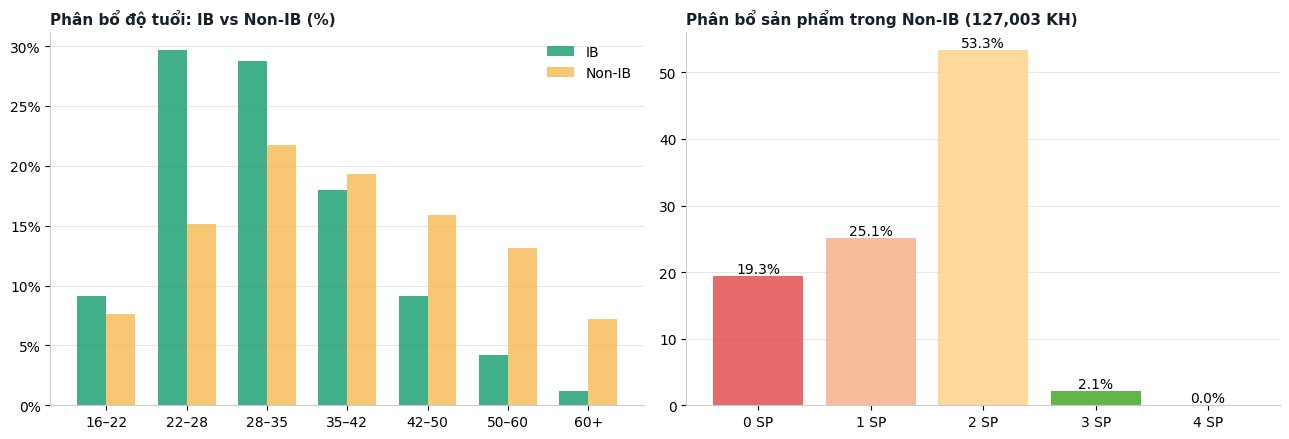

In [24]:
# Chart: Tuổi + SP Non-IB
bins_a = [16,22,28,35,42,50,60,np.inf]; lbl_a = ['16–22','22–28','28–35','35–42','42–50','50–60','60+']
b2 = base.assign(ab=pd.cut(base['AGE_AT_2019'],bins=bins_a,labels=lbl_a,right=False))
age_t = (b2.pivot_table(index='ab',columns='is_ib',values='CUSTOMER_NUMBER',aggfunc='count',observed=False)
         .fillna(0).rename(columns={False:'Non-IB',True:'IB'})
         .pipe(lambda t: t.div(t.sum(),axis=1)*100))
non_d = non['product_depth'].value_counts(normalize=True).sort_index()*100

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

x = np.arange(len(age_t))
axes[0].bar(x-0.18, age_t['IB'],     0.36, label='IB',     color=GREEN,  alpha=0.85)
axes[0].bar(x+0.18, age_t['Non-IB'], 0.36, label='Non-IB', color=YELLOW, alpha=0.85)
axes[0].set_xticks(x, age_t.index.astype(str)); axes[0].legend(frameon=False)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[0],'Phân bổ độ tuổi: IB vs Non-IB (%)')

axes[1].bar([f'{int(i)} SP' for i in non_d.index], non_d.values,
    color=[RED,'#f6b289','#ffd28b','#47a928',BLUE][:len(non_d)], alpha=0.85)
axes[1].bar_label(axes[1].containers[0],fmt='%.1f%%')
sax(axes[1],f'Phân bổ sản phẩm trong Non-IB ({len(non):,} KH)')

plt.tight_layout(); plt.show()

**Nhận xét:**
IB tập trung mạnh ở nhóm 22–35 tuổi (**58,3%**), Non-IB phân bổ đều hơn và nghiêng về nhóm trung niên 35–60 (**48,1%**). Tuy nhiên khoảng cách này không đủ để giải thích tại sao Non-IB chưa lên digital.

**53,3% Non-IB đang có 2 sản phẩm** — họ không phải KH mới hay KH không có quan hệ với NH. Sự phân tán từ 0 đến 4 SP cho thấy đây không phải một nhóm đồng nhất — không thể dùng cùng một cách tiếp cận.

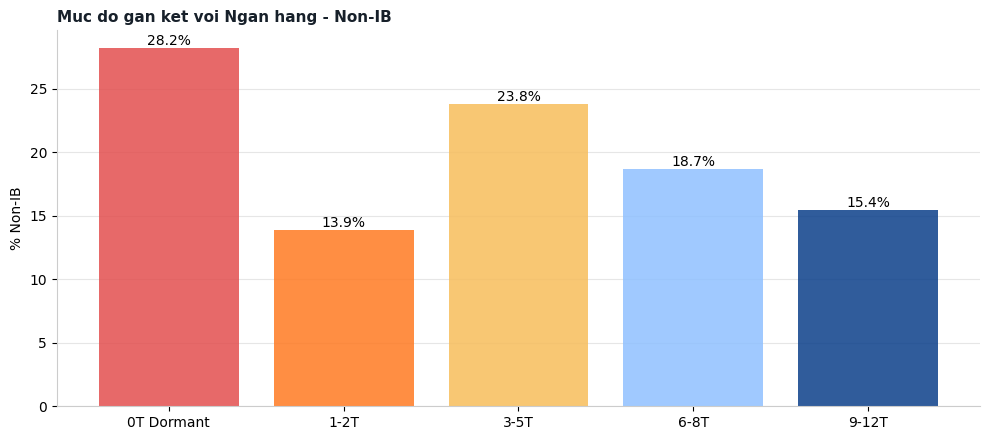

Dormant 0T: 35,805 (28.2%)
Gan ket 6+T: 43,308 (34.1%)


In [25]:
# Chart: Muc do gan ket Non-IB
non2 = non.copy()
non2['engaged_bucket'] = pd.cut(non2['bank_engagement_months'],
    bins=[-0.1, 0, 2, 5, 8, 12],
    labels=['0T Dormant', '1-2T', '3-5T', '6-8T', '9-12T'])
eng = non2['engaged_bucket'].value_counts(normalize=True).reindex(
    ['0T Dormant', '1-2T', '3-5T', '6-8T', '9-12T']) * 100

plt.figure(figsize=(10, 4.5))
bars = plt.bar(eng.index.astype(str), eng.values,
    color=[RED, ORANGE, YELLOW, LBLUE, BLUE], alpha=0.85)
plt.bar_label(bars, fmt='%.1f%%')
sax(plt.gca(), 'Muc do gan ket voi Ngan hang - Non-IB')
plt.ylabel('% Non-IB')
plt.tight_layout()
plt.show()

dormant = non2['bank_engagement_months'].eq(0).sum()
ge6     = non2['bank_engagement_months'].ge(6).sum()
print(f"Dormant 0T: {dormant:,} ({dormant/len(non)*100:.1f}%)")
print(f"Gan ket 6+T: {ge6:,} ({ge6/len(non)*100:.1f}%)")

**Nhận xét:**
Phân bổ gắn kết trải đều ở tất cả các mức — không có nhóm nào chiếm đa số áp đảo. **28,2%** hoàn toàn dormant (0 tháng active), nhưng đồng thời **34,1%** đang gắn kết từ 6 tháng trở lên.

Hai đầu cực cùng tồn tại trong một nhóm — đây là bằng chứng rõ ràng nhất cho thấy Non-IB cần được phân tách trước khi can thiệp, **không thể xử lý đồng loạt**.

## 5.2 Tín hiệu Digital-Ready trong Non-IB

In [26]:
# Compute ready flags
dep_mx = dep.groupby('CUSTOMER_NUMBER').agg(
    TD_ACCT_MAX=('COUNT_TD_ACCT','max'), MONTHS_W_DEP=('MONTH','nunique'),
    CA_BAL_LAST=('AVG_CA_BALANCE','last'))
lnd_mx = lnd.groupby('CUSTOMER_NUMBER').agg(LOAN_MAX=('COUNT_OF_LOAN','max'))
crd_mx = crd.groupby('CUSTOMER_NUMBER').agg(
    CC_MAX=('COUNT_CREDITCARD','max'), DC_MAX=('COUNT_DEBITCARD','max'))

non3 = non.join(dep_mx,on='CUSTOMER_NUMBER').join(lnd_mx,on='CUSTOMER_NUMBER').join(crd_mx,on='CUSTOMER_NUMBER')
for c in ['TD_ACCT_MAX','MONTHS_W_DEP','CA_BAL_LAST','LOAN_MAX','CC_MAX','DC_MAX']:
    non3[c] = non3[c].fillna(0)

non3['f_card']    = non3[['CC_MAX','DC_MAX']].gt(0).any(axis=1)
non3['f_td']      = non3['TD_ACCT_MAX'].gt(0)
non3['f_loan']    = non3['LOAN_MAX'].gt(0)
non3['f_young']   = non3['AGE_AT_2019'].between(22,41,inclusive='both') & non3['product_depth'].ge(2)
non3['f_engaged'] = non3['MONTHS_W_DEP'].ge(6)
non3['f_balance'] = non3['CA_BAL_LAST'].gt(10_000_000)
rcols = ['f_card','f_td','f_loan','f_young','f_engaged','f_balance']
non3['ready_score'] = non3[rcols].sum(axis=1).clip(upper=5)

ready = non3[rcols].mean()*100
ready.index = ['Có thẻ (CC/DC)','Có TD','Có vay','Trẻ 22–41t + ≥2SP','Engaged ≥6T','CA > 10M']
print(ready.to_string())
print(f"\nScore 0 (chưa sẵn sàng): {non3['ready_score'].eq(0).sum():,} ({non3['ready_score'].eq(0).mean()*100:.1f}%)")
print(f"Score ≥1 (có tín hiệu)  : {non3['ready_score'].ge(1).sum():,} ({non3['ready_score'].ge(1).mean()*100:.1f}%)")

Có thẻ (CC/DC)       30.158343
Có TD                20.812894
Có vay               28.561530
Trẻ 22–41t + ≥2SP    30.758329
Engaged ≥6T          34.099982
CA > 10M              1.913341

Score 0 (chưa sẵn sàng): 30,410 (23.9%)
Score ≥1 (có tín hiệu)  : 96,593 (76.1%)


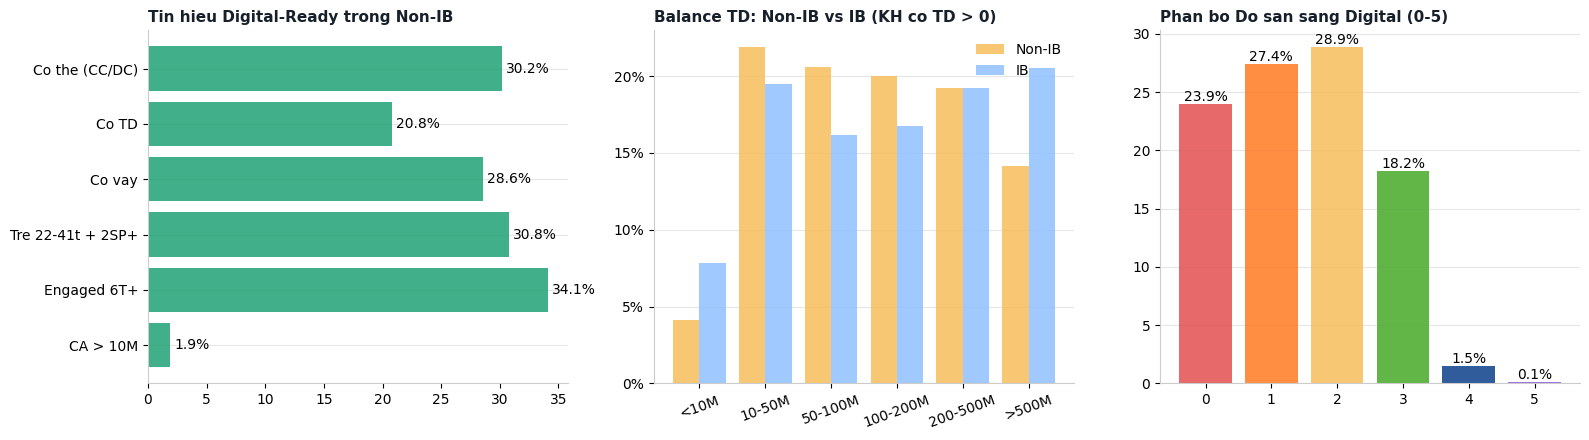

Median TD Non-IB: 110M  |  Median TD IB: 137M


In [27]:
# Chart: Ready signals + TD balance + Score distribution
non_td = non.loc[non['AVG_TD_BALANCE'].fillna(0).gt(0), 'AVG_TD_BALANCE']
ib_td  = ib.loc[ ib['AVG_TD_BALANCE'].fillna(0).gt(0),  'AVG_TD_BALANCE']
td_bins = [-0.1, 10e6, 50e6, 100e6, 200e6, 500e6, np.inf]
td_lbl  = ['<10M', '10-50M', '50-100M', '100-200M', '200-500M', '>500M']
ntb = pd.cut(non_td, bins=td_bins, labels=td_lbl).value_counts(normalize=True).reindex(td_lbl) * 100
itb = pd.cut(ib_td,  bins=td_bins, labels=td_lbl).value_counts(normalize=True).reindex(td_lbl) * 100
score_d = non3['ready_score'].value_counts(normalize=True).sort_index() * 100

ready_labels = ['Co the (CC/DC)', 'Co TD', 'Co vay', 'Tre 22-41t + 2SP+', 'Engaged 6T+', 'CA > 10M']
ready_vals = non3[['f_card','f_td','f_loan','f_young','f_engaged','f_balance']].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bars = axes[0].barh(ready_labels[::-1], ready_vals.values[::-1], color=GREEN, alpha=0.85)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
sax(axes[0], 'Tin hieu Digital-Ready trong Non-IB')

x2 = np.arange(len(td_lbl))
axes[1].bar(x2 - 0.2, ntb.values, 0.4, label='Non-IB', color=YELLOW, alpha=0.85)
axes[1].bar(x2 + 0.2, itb.values, 0.4, label='IB',     color=LBLUE,  alpha=0.85)
axes[1].set_xticks(x2, td_lbl, rotation=20)
axes[1].legend(frameon=False)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
sax(axes[1], 'Balance TD: Non-IB vs IB (KH co TD > 0)')

axes[2].bar(score_d.index.astype(str), score_d.values,
    color=[RED, ORANGE, YELLOW, '#47a928', BLUE, '#8e55d8'][:len(score_d)], alpha=0.85)
axes[2].bar_label(axes[2].containers[0], fmt='%.1f%%')
sax(axes[2], 'Phan bo Do san sang Digital (0-5)')

plt.tight_layout()
plt.show()

print(f"Median TD Non-IB: {non_td.median()/1e6:.0f}M  |  Median TD IB: {ib_td.median()/1e6:.0f}M")

**Nhận xét:**
Phần lớn Non-IB không phải nhóm "trắng tay" — **34,1%** đang gắn kết ≥6 tháng, **34,3%** là nhóm trẻ 22–41 tuổi có từ 2 SP, **30,2%** đã có thẻ.

Non-IB tập trung mạnh ở dải **50–200M** (40,6%), trong khi IB phân bổ đều hơn. Median TD Non-IB đạt **110M** — nhóm Non-IB đang gửi tiết kiệm kỳ hạn thực sự tại NH. Điều duy nhất họ chưa làm là dùng kênh số.

**23,9%** score 0 — chưa sẵn sàng, cần approach riêng. **76,1%** có ít nhất 1 tín hiệu, trong đó nhóm score 2–3 chiếm gần **47%** — vùng "tiềm năng chờ được kích hoạt". Phân bổ **lệch phải** cho thấy phần lớn Non-IB đang ở giai đoạn giữa.

## 5.3 Các tín hiệu không đi cùng nhau — Rule đơn giản không thể xử lý

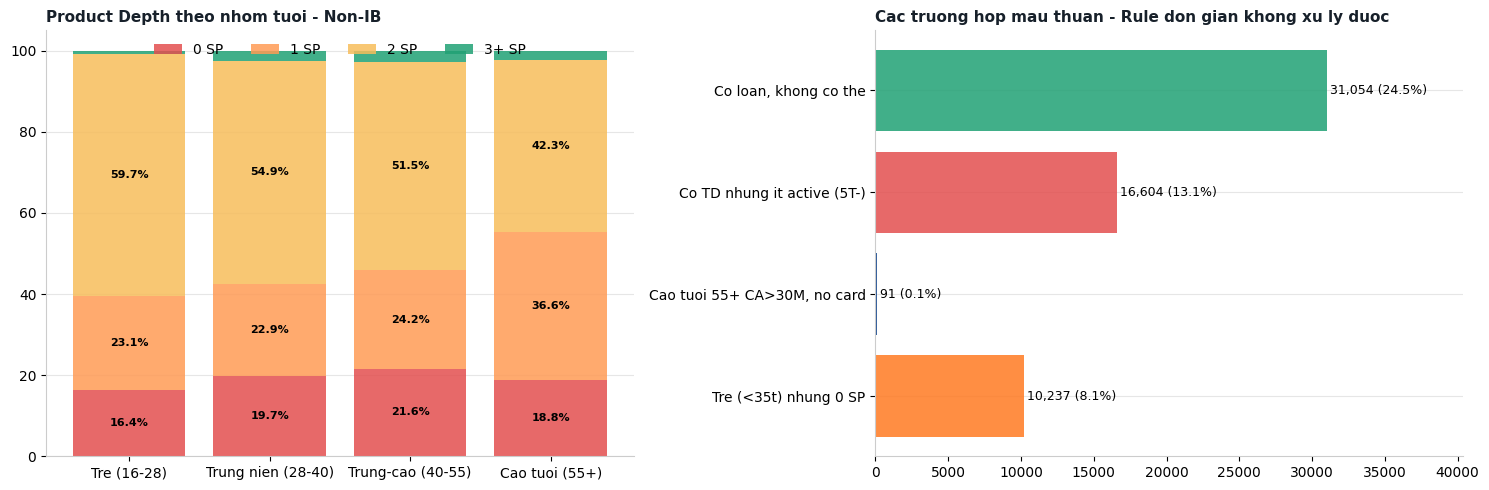

  Co loan, khong co the                   : 31,054
  Co TD nhung it active (5T-)             : 16,604
  Cao tuoi 55+ CA>30M, no card            : 91
  Tre (<35t) nhung 0 SP                   : 10,237


In [28]:
# Chart: Product depth by age + Contradictory cases
age_lbl4 = ['Tre (16-28)', 'Trung nien (28-40)', 'Trung-cao (40-55)', 'Cao tuoi (55+)']
non4 = non.assign(
    ag=pd.cut(non['AGE_AT_2019'], bins=[16,28,40,55,np.inf], labels=age_lbl4, right=False),
    dg=non['product_depth'].clip(upper=3).map({0:'0 SP', 1:'1 SP', 2:'2 SP', 3:'3+ SP'}))
stacked = (pd.crosstab(non4['ag'], non4['dg'], normalize='index') * 100
           ).reindex(index=age_lbl4, columns=['0 SP','1 SP','2 SP','3+ SP'], fill_value=0)

age_non = non3['AGE_AT_2019']
has_card_n = non3[['CC_MAX','DC_MAX']].gt(0).any(axis=1)
cases = pd.Series({
    'Co loan, khong co the'       : (non3['LOAN_MAX'].gt(0) & ~has_card_n).sum(),
    'Co TD nhung it active (5T-)' : (non3['TD_ACCT_MAX'].gt(0) & non3['MONTHS_W_DEP'].le(5)).sum(),
    'Cao tuoi 55+ CA>30M, no card': (age_non.ge(55) & non3['CA_BAL_LAST'].gt(30e6) & ~has_card_n).sum(),
    'Tre (<35t) nhung 0 SP'       : (age_non.lt(35) & non3['product_depth'].eq(0)).sum(),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bottom = np.zeros(len(stacked))
for col, color in zip(['0 SP','1 SP','2 SP','3+ SP'], [RED,'#ff9b55',YELLOW,GREEN]):
    bars = axes[0].bar(stacked.index.astype(str), stacked[col], bottom=bottom, label=col, color=color, alpha=0.85)
    for j,(v,b) in enumerate(zip(stacked[col], bottom)):
        if v > 5:
            axes[0].text(j, b+v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold')
    bottom += stacked[col].values
axes[0].legend(frameon=False, ncol=4, loc='upper center')
axes[0].tick_params(axis='x', rotation=0)
sax(axes[0], 'Product Depth theo nhom tuoi - Non-IB')

bars2 = axes[1].barh(cases.index[::-1], cases.values[::-1],
    color=[ORANGE, BLUE, RED, GREEN], alpha=0.85)
for i,(k,v) in enumerate(zip(cases.index[::-1], cases.values[::-1])):
    axes[1].text(v+200, i, f'{v:,} ({v/len(non)*100:.1f}%)', va='center', fontsize=9)
axes[1].set_xlim(0, cases.max()*1.3)
sax(axes[1], 'Cac truong hop mau thuan - Rule don gian khong xu ly duoc')

plt.tight_layout()
plt.show()

for k,v in cases.items():
    print(f"  {k:<40}: {v:,}")

**Nhận xét:**
Nhóm trẻ 16–28 có tỷ lệ 2 SP cao nhất (**59,7%**) — họ đang gắn kết tốt hơn vẻ ngoài. Nhóm 55+: **36,6%** có 1 SP và **2,3%** có 3+ SP — phần lớn dừng ở ≤1 SP, hành vi truyền thống. Không nhóm tuổi nào chiếm ưu thế tuyệt đối về 3+ SP — **chiến lược nhắm theo tuổi đơn thuần là không đủ**.

**31.054 KH** có loan nhưng không có thẻ; **16.604 KH** có TD nhưng ít active; **10.237 KH** trẻ nhưng 0 SP — sự đa dạng này chứng minh không có rule nào phù hợp cho tất cả. Đây là lý do cần **Clustering**.

## 5.4 Tổng kết — Vấn đề chính nhóm Non-IB

In [29]:
print("="*62)
print("  VẤN ĐỀ:")
print("  NH cần nhận diện và khai thác KH có tín hiệu digital-ready")
print("="*62)
print()
print(f"  127.000 KH Non-IB đang bị nhìn như một khối đồng nhất")
print(f"  trong khi thực tế trải rộng từ dormant → tín dụng phức tạp")
print()
print(f"  • {non3['ready_score'].eq(0).sum():,} KH ({non3['ready_score'].eq(0).mean()*100:.1f}%) — Score 0, chưa sẵn sàng, cần approach riêng")
print(f"  • {non3['ready_score'].ge(1).sum():,} KH ({non3['ready_score'].ge(1).mean()*100:.1f}%) — ≥1 tín hiệu, tiềm năng chờ khai thác")
print(f"  • Median TD (KH có TD): {non_td.median()/1e6:.0f}M — tập trung dải 50–200M")
print(f"  • {cases['Co loan, khong co the']:,} KH có vay nhưng không có thẻ")
print()
print("  HƯỚNG TIẾP CẬN:")
print("  Non-IB không có hành vi số để phân tích trực tiếp —")
print("  nhưng để lại dấu vết qua SP sở hữu, balance, mức độ")
print("  gắn kết truyền thống và nhân khẩu học.")
print("  → Clustering dựa trên những tín hiệu này là cách duy nhất")
print("    để NH nhận ra đúng nhóm cần ưu tiên.")

  VẤN ĐỀ:
  NH cần nhận diện và khai thác KH có tín hiệu digital-ready

  127.000 KH Non-IB đang bị nhìn như một khối đồng nhất
  trong khi thực tế trải rộng từ dormant → tín dụng phức tạp

  • 30,410 KH (23.9%) — Score 0, chưa sẵn sàng, cần approach riêng
  • 96,593 KH (76.1%) — ≥1 tín hiệu, tiềm năng chờ khai thác
  • Median TD (KH có TD): 110M — tập trung dải 50–200M
  • 31,054 KH có vay nhưng không có thẻ

  HƯỚNG TIẾP CẬN:
  Non-IB không có hành vi số để phân tích trực tiếp —
  nhưng để lại dấu vết qua SP sở hữu, balance, mức độ
  gắn kết truyền thống và nhân khẩu học.
  → Clustering dựa trên những tín hiệu này là cách duy nhất
    để NH nhận ra đúng nhóm cần ưu tiên.
